<a href="https://colab.research.google.com/github/MustafaLearnsToCode/wtp-estimation-error-research/blob/main/wtp_noise_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

SEED = 42
rng = np.random.default_rng(SEED)

#Loading in the Dataset and Initial Exploration:

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(url)

print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print(df.describe())

print(df.isnull().sum())

print(df.info())

            Quantity                    InvoiceDate      UnitPrice  \
count  541909.000000                         541909  541909.000000   
mean        9.552250  2011-07-04 13:34:57.156386048       4.611114   
min    -80995.000000            2010-12-01 08:26:00  -11062.060000   
25%         1.000000            2011-03-28 11:34:00       1.250000   
50%         3.000000            2011-07-19 17:17:00       2.080000   
75%        10.000000            2011-10-19 11:27:00       4.130000   
max     80995.000000            2011-12-09 12:50:00   38970.000000   
std       218.081158                            NaN      96.759853   

          CustomerID  
count  406829.000000  
mean    15287.690570  
min     12346.000000  
25%     13953.000000  
50%     15152.000000  
75%     16791.000000  
max     18287.000000  
std      1713.600303  
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country 

#Checking For and Removing Cancellations

In [4]:
invoice_cancel = df['InvoiceNo'].astype(str).str.startswith("C")
print(invoice_cancel.sum())

df = df[~df['InvoiceNo'].astype(str).str.startswith("C")]

print(df.shape)

9288
(532621, 8)


#Checking For and Removing Negative Quantities

In [5]:
print((df['Quantity'] <= 0).sum())

df = df[df['Quantity'] > 0]

print(df.shape)

1336
(531285, 8)


#Checking For and Removing Negative Prices

In [6]:
print((df['UnitPrice'] <= 0).sum())

df = df[df["UnitPrice"] > 0]

print(df.shape)

1181
(530104, 8)


#Creating Total Spend

In [7]:
df["TotalSpend"] = df["Quantity"]*df['UnitPrice']

print(df[['TotalSpend', "UnitPrice", "Quantity"]].head())

   TotalSpend  UnitPrice  Quantity
0       15.30       2.55         6
1       20.34       3.39         6
2       22.00       2.75         8
3       20.34       3.39         6
4       20.34       3.39         6


#Building Customer Profiles

In [8]:
print(df['CustomerID'].unique())

customer_profiles = (
    df.groupby('CustomerID')
    .agg(TotalSpend=('TotalSpend', 'sum'),
         PurchaseCount=('InvoiceNo', 'nunique'))
    .reset_index())

# AOV is per invoice, not per line item
customer_profiles['AvgOrderValue'] = (
    customer_profiles['TotalSpend'] / customer_profiles['PurchaseCount']
)

# sanity check: should print True
print(np.allclose(
    customer_profiles['AvgOrderValue'] * customer_profiles['PurchaseCount'],
    customer_profiles['TotalSpend']
))
customer_profiles.head()
customer_profiles.head()

[17850. 13047. 12583. ... 13298. 14569. 12713.]
True


,CustomerID,TotalSpend,PurchaseCount,AvgOrderValue
0,12346.0,77183.60,1,77183.600000
1,12347.0,4310.00,7,615.714286
2,12348.0,1797.24,4,449.310000
3,12349.0,1757.55,1,1757.550000
4,12350.0,334.40,1,334.400000


In [9]:
print(customer_profiles[['TotalSpend','PurchaseCount','AvgOrderValue']].describe())
print(customer_profiles[customer_profiles['CustomerID']==12347])

          TotalSpend  PurchaseCount  AvgOrderValue
count    4338.000000    4338.000000    4338.000000
mean     2054.266460       4.272015     419.166289
std      8989.230441       7.697998    1796.537944
min         3.750000       1.000000       3.450000
25%       307.415000       1.000000     178.625000
50%       674.485000       2.000000     293.900000
75%      1661.740000       5.000000     430.113750
max    280206.020000     209.000000   84236.250000
   CustomerID  TotalSpend  PurchaseCount  AvgOrderValue
1     12347.0      4310.0              7     615.714286


#Creating a Purchase Frequency Column

In [10]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df['InvoiceDate'].min())
print(df['InvoiceDate'].max())

dataset_days = (df['InvoiceDate'].max() - df['InvoiceDate'].min()).days

print(dataset_days)

#Purchase frequency metric for the customer profiles
customer_profiles['PurchaseFrequency'] = (
    customer_profiles['PurchaseCount']/dataset_days
)

print(customer_profiles)
customer_profiles.describe()

2010-12-01 08:26:00
2011-12-09 12:50:00
373
      CustomerID  TotalSpend  PurchaseCount  AvgOrderValue  PurchaseFrequency
0        12346.0    77183.60              1   77183.600000           0.002681
1        12347.0     4310.00              7     615.714286           0.018767
2        12348.0     1797.24              4     449.310000           0.010724
3        12349.0     1757.55              1    1757.550000           0.002681
4        12350.0      334.40              1     334.400000           0.002681
...          ...         ...            ...            ...                ...
4333     18280.0      180.60              1     180.600000           0.002681
4334     18281.0       80.82              1      80.820000           0.002681
4335     18282.0      178.05              2      89.025000           0.005362
4336     18283.0     2094.88             16     130.930000           0.042895
4337     18287.0     1837.28              3     612.426667           0.008043

[4338 rows x 5 colu

,CustomerID,TotalSpend,PurchaseCount,AvgOrderValue,PurchaseFrequency
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,2054.266460,4.272015,419.166289,0.011453
std,1721.808492,8989.230441,7.697998,1796.537944,0.020638
min,12346.000000,3.750000,1.000000,3.450000,0.002681
25%,13813.250000,307.415000,1.000000,178.625000,0.002681
50%,15299.500000,674.485000,2.000000,293.900000,0.005362
75%,16778.750000,1661.740000,5.000000,430.113750,0.013405
max,18287.000000,280206.020000,209.000000,84236.250000,0.560322


## Numbers and Sanity Checks for Paper

In [11]:
print("DATA SECTION NUMBERS")
print(f"cleaned line-item records : {len(df):,}")
print(f"unique customers          : {df['CustomerID'].nunique():,}")
print(f"customer_profiles rows    : {len(customer_profiles):,}")
print(f"countries                 : {df['Country'].nunique()}")
print(f"UK share of records       : {(df['Country']=='United Kingdom').mean()*100:.1f}%")
print(f"date range                : {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"observation window (days) : {(df['InvoiceDate'].max()-df['InvoiceDate'].min()).days}")

print("\nFEATURE SUMMARY")
print(customer_profiles[['TotalSpend','PurchaseCount',
                         'AvgOrderValue','PurchaseFrequency']].describe().round(2))

print("\nSANITY CHECKS")
print("AOV x Count == TotalSpend :",
      np.allclose(customer_profiles['AvgOrderValue']*customer_profiles['PurchaseCount'],
                  customer_profiles['TotalSpend']))
print("corr(logPurchaseCount, logPurchaseFrequency) :",
      round(np.log1p(customer_profiles['PurchaseCount']).corr(
            np.log1p(customer_profiles['PurchaseFrequency'])), 4))

DATA SECTION NUMBERS
cleaned line-item records : 530,104
unique customers          : 4,338
customer_profiles rows    : 4,338
countries                 : 38
UK share of records       : 91.5%
date range                : 2010-12-01 08:26:00 to 2011-12-09 12:50:00
observation window (days) : 373

FEATURE SUMMARY
       TotalSpend  PurchaseCount  AvgOrderValue  PurchaseFrequency
count     4338.00        4338.00        4338.00            4338.00
mean      2054.27           4.27         419.17               0.01
std       8989.23           7.70        1796.54               0.02
min          3.75           1.00           3.45               0.00
25%        307.41           1.00         178.62               0.00
50%        674.48           2.00         293.90               0.01
75%       1661.74           5.00         430.11               0.01
max     280206.02         209.00       84236.25               0.56

SANITY CHECKS
AOV x Count == TotalSpend : True
corr(logPurchaseCount, logPurchaseFrequ

In [12]:
missing = df['CustomerID'].isna()
print("records with no CustomerID:", missing.sum())
print("share of cleaned:", round(missing.mean()*100, 1), "%")
print("records remaining:", (~missing).sum())
print("UK share (analytical sample):",
      round((df.loc[~missing,'Country']=='United Kingdom').mean()*100, 1), "%")
print("countries (analytical sample):", df.loc[~missing,'Country'].nunique())

records with no CustomerID: 132220
share of cleaned: 24.9 %
records remaining: 397884
UK share (analytical sample): 89.1 %
countries (analytical sample): 37


In [13]:
df = df[df['CustomerID'].notna()]
print(df.shape)

(397884, 9)


##Correlation Check For Features

In [14]:
print(customer_profiles['PurchaseCount'].corr(customer_profiles['PurchaseFrequency']))

1.0


#Looking at Customer Profile Distribuions

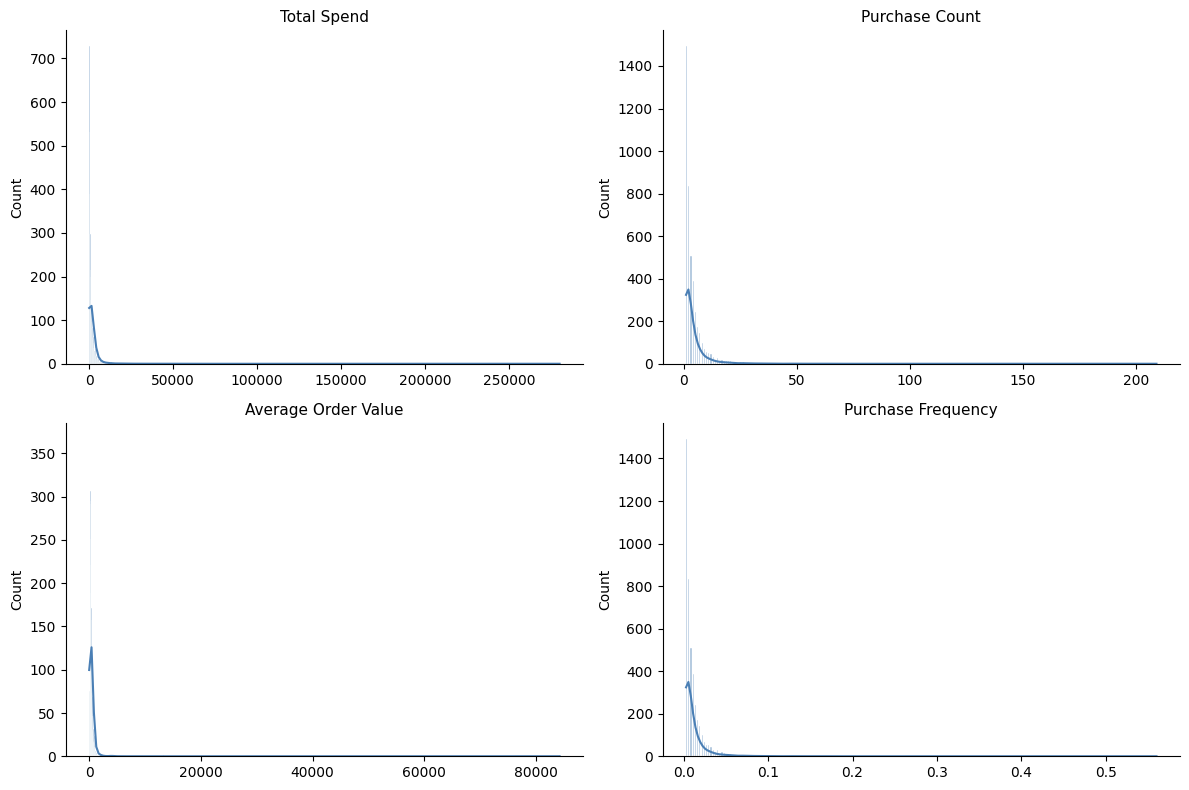

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

variables = ['TotalSpend', 'PurchaseCount',
             'AvgOrderValue', 'PurchaseFrequency']
titles = ['Total Spend', 'Purchase Count',
          'Average Order Value', 'Purchase Frequency']

for ax, var, title in zip(axes.flatten(), variables, titles):
    sns.histplot(customer_profiles[var], kde=True, ax=ax,
                 color='#4a7fb5', edgecolor='white', linewidth=0.3)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('raw_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Looking At Extreme Order Values and Total Spend


In [16]:
print(f"AvgOrderValue:\n{customer_profiles.nlargest(10, 'AvgOrderValue')}")
print(f"TotalSpend:\n{customer_profiles.nlargest(10, 'TotalSpend')}")

AvgOrderValue:
      CustomerID  TotalSpend  PurchaseCount  AvgOrderValue  PurchaseFrequency
3008     16446.0   168472.50              2   84236.250000           0.005362
0        12346.0    77183.60              1   77183.600000           0.002681
2502     15749.0    44534.30              3   14844.766667           0.008043
2011     15098.0    39916.50              3   13305.500000           0.008043
10       12357.0     6207.67              1    6207.670000           0.002681
55       12415.0   124914.53             21    5948.310952           0.056300
196      12590.0     9864.26              2    4932.130000           0.005362
278      12688.0     4873.81              1    4873.810000           0.002681
329      12752.0     4366.78              1    4366.780000           0.002681
4201     18102.0   259657.30             60    4327.621667           0.160858
TotalSpend:
      CustomerID  TotalSpend  PurchaseCount  AvgOrderValue  PurchaseFrequency
1689     14646.0   280206.02         

# Creating a copy Customer Profiles

In [17]:
customer_profiles_copy = customer_profiles.copy()

###EXPLORATORY METHODS TESTED:
*   **IQR Methods Outlier Removal:** Dropped because High-spending customers are econcomically relevant to research; not to be removed.
*   **Winsorization:** Dropped due to a similar reason for IQR Method. Bulk-buying customers are important to research and there was no clean separation.
*   **K-means:** Chose K-means because data had no natural segmentation when displayed visually.
*   **K-means on Raw Data:** Extreme buyers dominate clusters on base numerical values, making log features a better representation.
*   **4-clusters:** Tried to isolate bulk buyers in their own cluster, but they don't separate cleanly. Chose 3-clusters in instead.



# K-Means Diagnostic Using Raw Features

Testing K-Means on raw scaled features. Is useful as a comparison, but is not the final model because raw spending variables are highly skewed and can allow extreme buyers to dominate the clusters.


,TotalSpend,PurchaseCount,AvgOrderValue,PurchaseFrequency
0,77183.60,1,77183.600000,0.002681
1,4310.00,7,615.714286,0.018767
2,1797.24,4,449.310000,0.010724
3,1757.55,1,1757.550000,0.002681
4,334.40,1,334.400000,0.002681


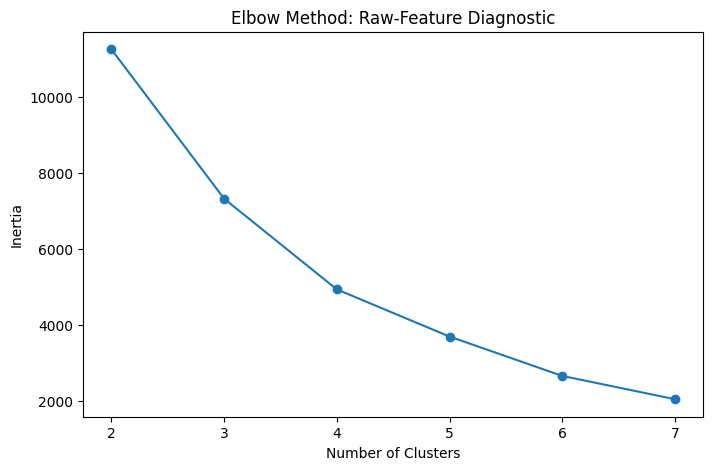

In [18]:
raw_features = ['TotalSpend', 'PurchaseCount', 'AvgOrderValue', 'PurchaseFrequency']
raw_segmentation_df = customer_profiles.copy()

X_raw = raw_segmentation_df[raw_features].copy()
display(X_raw.head())

raw_scaler = StandardScaler()
X_raw_scaled = raw_scaler.fit_transform(X_raw)

# Elbow Method for the raw-feature diagnostic
raw_inertias = []
k_range_raw = range(2, 8)

for k in k_range_raw:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    kmeans.fit(X_raw_scaled)
    raw_inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range_raw, raw_inertias, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method: Raw-Feature Diagnostic')
plt.show()


# Silhouette Score for Raw-Feature Diagnostic

This evaluates the exploratory raw-feature K-Means setup above. The final model uses log-transformed features.


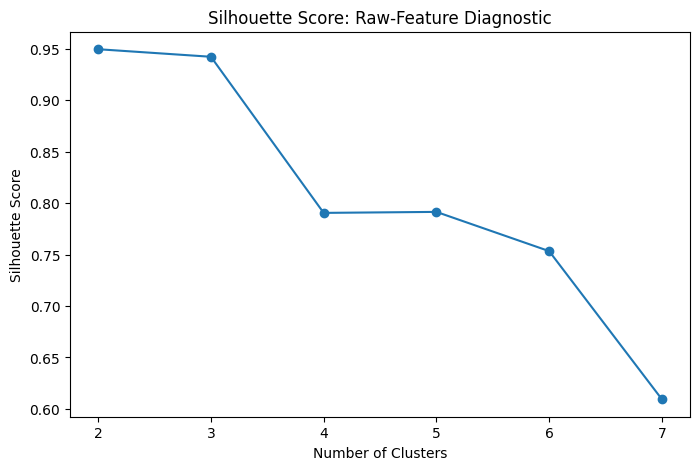

In [19]:
# Higher silhouette scores indicate better-separated clusters

raw_silhouette_scores = []

for k in k_range_raw:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = kmeans.fit_predict(X_raw_scaled)
    raw_silhouette_scores.append(silhouette_score(X_raw_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(k_range_raw, raw_silhouette_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score: Raw-Feature Diagnostic')
plt.show()


# Final K-Means Segmentation: Our Log-Transformed Features

This is the final 3-cluster segmentation used for the simulation. The log transformation reduces the influence of extreme high-spending customers while keeping those customers in the dataset.


In [20]:
segmentation_df = customer_profiles.copy()

# Create log-transformed features
# np.log1p(x) calculates log(1 + x), which is safe when x is 0
segmentation_df['log_TotalSpend'] = np.log1p(segmentation_df['TotalSpend'])
segmentation_df['log_PurchaseCount'] = np.log1p(segmentation_df['PurchaseCount'])
segmentation_df['log_AvgOrderValue'] = np.log1p(segmentation_df['AvgOrderValue'])
segmentation_df['log_PurchaseFrequency'] = np.log1p(segmentation_df['PurchaseFrequency'])

log_features = [
    'log_TotalSpend',
    'log_PurchaseCount',
    'log_AvgOrderValue',
    'log_PurchaseFrequency'
]

# Select only the variables used for clustering
# The .copy() protects the original dataframe from accidental changes
X_log = segmentation_df[log_features].copy()

# Standardize features so each variable has comparable influence
log_scaler = StandardScaler()
X_scaled_log = log_scaler.fit_transform(X_log)

# Run final 3-cluster K-Means model
kmeans_3 = KMeans(
    n_clusters=3,
    random_state=SEED,
    n_init=10
)

segmentation_df['KMeansCluster_3'] = kmeans_3.fit_predict(X_scaled_log)

# Summarize clusters to interpret them economically
cluster_summary_3 = segmentation_df.groupby('KMeansCluster_3').agg(
    CustomerCount=('CustomerID', 'count'),
    AvgTotalSpend=('TotalSpend', 'mean'),
    MedianTotalSpend=('TotalSpend', 'median'),
    MinTotalSpend=('TotalSpend', 'min'),
    MaxTotalSpend=('TotalSpend', 'max'),
    AvgPurchaseCount=('PurchaseCount', 'mean'),
    AvgOrderValue=('AvgOrderValue', 'mean'),
    AvgPurchaseFrequency=('PurchaseFrequency', 'mean')
).reset_index()

# Cluster numbers are arbitrary
# Sorting by AvgTotalSpend lets us map them to Low, Medium, and High
cluster_summary_3 = cluster_summary_3.sort_values('AvgTotalSpend')

display(cluster_summary_3)

sorted_clusters_3 = cluster_summary_3['KMeansCluster_3'].tolist()

label_map_3 = {
    sorted_clusters_3[0]: 'Low',
    sorted_clusters_3[1]: 'Medium',
    sorted_clusters_3[2]: 'High'
}

segmentation_df['KMeansSegment_3'] = segmentation_df['KMeansCluster_3'].map(label_map_3)

# Check the readable segment labels
display(segmentation_df[['CustomerID', 'TotalSpend', 'KMeansCluster_3', 'KMeansSegment_3']].head())

# Check segment counts
display(segmentation_df['KMeansSegment_3'].value_counts())


,KMeansCluster_3,CustomerCount,AvgTotalSpend,MedianTotalSpend,MinTotalSpend,MaxTotalSpend,AvgPurchaseCount,AvgOrderValue,AvgPurchaseFrequency
0,0,1889,282.437407,272.040,3.75,694.40,1.572260,200.137968,0.004215
2,2,2016,1759.652377,1201.275,462.95,168472.50,3.743552,600.350699,0.010036
1,1,433,11155.714665,5226.230,1296.44,280206.02,18.510393,531.121782,0.049626


,CustomerID,TotalSpend,KMeansCluster_3,KMeansSegment_3
0,12346.0,77183.60,2,Medium
1,12347.0,4310.00,2,Medium
2,12348.0,1797.24,2,Medium
3,12349.0,1757.55,2,Medium
4,12350.0,334.40,0,Low


,count
KMeansSegment_3,
Medium,2016
Low,1889
High,433


# Log Customer Profile Distributions

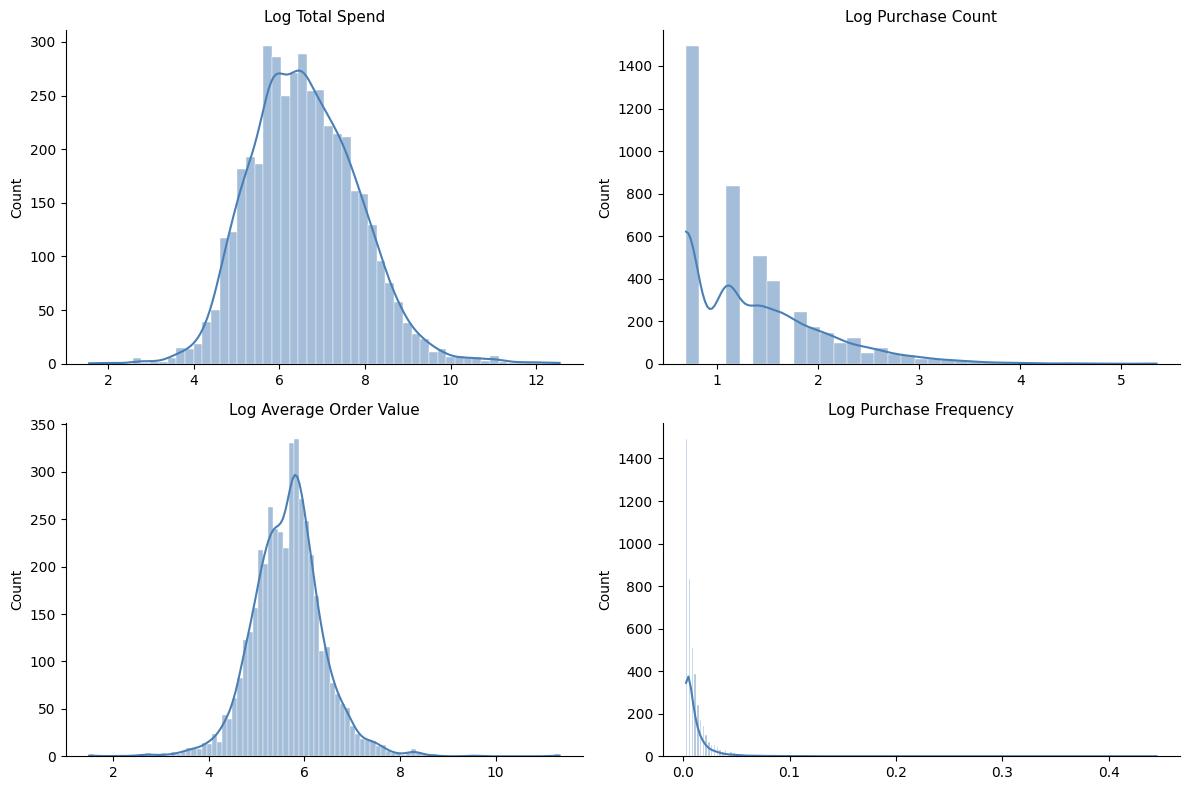

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

variables = ['log_TotalSpend', 'log_PurchaseCount',
             'log_AvgOrderValue', 'log_PurchaseFrequency']
titles = ['Log Total Spend', 'Log Purchase Count',
          'Log Average Order Value', 'Log Purchase Frequency']

for ax, var, title in zip(axes.flatten(), variables, titles):
    sns.histplot(segmentation_df[var], kde=True, ax=ax,
                 color='#4a7fb5', edgecolor='white', linewidth=0.3)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('logged_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Log K-Means Diagnostic

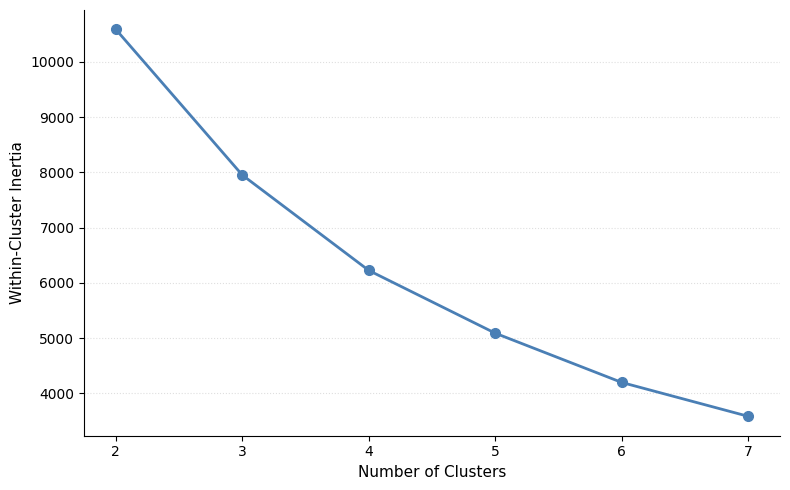

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select the log-transformed features
log_features = ['log_TotalSpend', 'log_PurchaseCount', 'log_AvgOrderValue', 'log_PurchaseFrequency']
X_log = segmentation_df[log_features]

# Scale them
log_scaler = StandardScaler()
X_scaled_log = log_scaler.fit_transform(X_log)

# Elbow method on scaled log features
inertias = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_log)
    inertias.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(k_range, inertias, marker='o', color='#4a7fb5',
        linewidth=2, markersize=7)

ax.set_xlabel('Number of Clusters', fontsize=11)
ax.set_ylabel('Within-Cluster Inertia', fontsize=11)

ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

# Log Silhouette Score

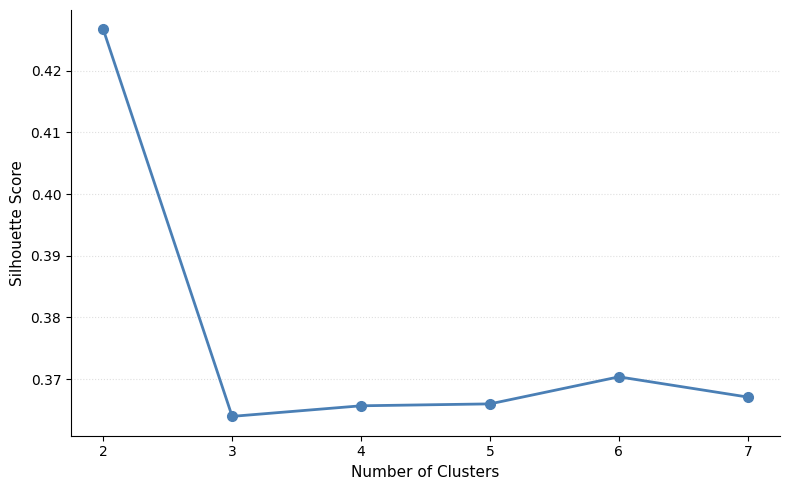

k=2: silhouette score = 0.4267
k=3: silhouette score = 0.3640
k=4: silhouette score = 0.3657
k=5: silhouette score = 0.3660
k=6: silhouette score = 0.3704
k=7: silhouette score = 0.3671


In [23]:
from sklearn.metrics import silhouette_score

sil_scores = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled_log)
    score = silhouette_score(X_scaled_log, labels)
    sil_scores.append(score)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(k_range, sil_scores, marker='o', color='#4a7fb5',
        linewidth=2, markersize=7)

ax.set_xlabel('Number of Clusters', fontsize=11)
ax.set_ylabel('Silhouette Score', fontsize=11)

ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('silhouette_scores.png', dpi=300, bbox_inches='tight')
plt.show()

# Print the scores so you can see exact values
for k, score in zip(k_range, sil_scores):
    print(f"k={k}: silhouette score = {score:.4f}")

# Create Segment-Level Parameters for WTP Distributions

These empirical segment means and standard deviations are used to parameterize the simulated WTP distributions.


In [24]:
segment_params = segmentation_df.groupby('KMeansSegment_3').agg(
    mean_spend=('TotalSpend', 'mean'),
    std_spend=('TotalSpend', 'std'),
    count=('CustomerID', 'count')
)

display(segment_params)


,mean_spend,std_spend,count
KMeansSegment_3,,,
High,11155.714665,24909.199505,433
Low,282.437407,144.316778,1889
Medium,1759.652377,4477.778656,2016


# Generate True WTP: Log-Normal and Gamma Robustness Check

The normal distribution is not used because it can generate negative WTP values. We use log-normal WTP and gamma is used as a robustness check.


In [25]:
# Reset the random generator so this cell gives the same results
# each time it is rerun
rng = np.random.default_rng(SEED)

'''
def generate_true_wtp_normal(row, params):
    segment = row['KMeansSegment_3']
    mean = params.loc[segment, 'mean_spend']
    std = params.loc[segment, 'std_spend']

    raw_wtp = rng.normal(mean, std)

    # If we kept the normal model, we would need to floor it at TotalSpend.
    true_wtp = max(raw_wtp, row['TotalSpend'], 0)

    return raw_wtp, true_wtp
'''


# np.random.lognormal does not use the real-world mean and std directly
# It uses the mean and standard deviation of the log of the variable

def lognormal_params(mean, std):
    if mean <= 0:
        raise ValueError("Mean spending must be positive for a log-normal distribution.")

    if std <= 0 or pd.isna(std):
        # If there is no variation in a segment, use a degenerate log-normal
        # centered at the segment mean.
        return np.log(mean), 0

    sigma_squared = np.log(1 + (std**2 / mean**2))
    sigma = np.sqrt(sigma_squared)
    mu = np.log(mean) - 0.5 * sigma_squared

    return mu, sigma



# This is the main WTP model
def generate_true_wtp_lognormal_floor(row):
    segment = row['KMeansSegment_3']

    mean = segment_params.loc[segment, 'mean_spend']
    std = segment_params.loc[segment, 'std_spend']

    mu, sigma = lognormal_params(mean, std)

    raw_wtp = rng.lognormal(mean=mu, sigma=sigma)

    true_wtp = max(raw_wtp, row['TotalSpend'])

    return raw_wtp, true_wtp



# The gamma distribution also only produces positive values
# We use it as a robustness check to see whether the final results
# depend heavily on the log-normal assumption

def gamma_params(mean, std):
    if mean <= 0:
        raise ValueError("Mean spending must be positive for a gamma distribution.")

    if std <= 0 or pd.isna(std):
        # If there is no variation in a segment, use an extremely concentrated
        # gamma distribution around the segment mean
        shape = 1e6
        scale = mean / shape
        return shape, scale

    shape = (mean / std) ** 2
    scale = (std ** 2) / mean

    return shape, scale


# Robustness check using gamma floor
def generate_true_wtp_gamma_floor(row):
    segment = row['KMeansSegment_3']

    mean = segment_params.loc[segment, 'mean_spend']
    std = segment_params.loc[segment, 'std_spend']

    shape, scale = gamma_params(mean, std)

    raw_wtp = rng.gamma(shape=shape, scale=scale)

    true_wtp = max(raw_wtp, row['TotalSpend'])

    return raw_wtp, true_wtp



# Apply the log-normal WTP generation

lognormal_results = segmentation_df.apply(
    generate_true_wtp_lognormal_floor,
    axis=1,
    result_type='expand'
)

segmentation_df['WTP_lognormal_raw'] = lognormal_results[0]
segmentation_df['TrueWTP_lognormal'] = lognormal_results[1]


# Apply the gamma WTP generation

gamma_results = segmentation_df.apply(
    generate_true_wtp_gamma_floor,
    axis=1,
    result_type='expand'
)

segmentation_df['WTP_gamma_raw'] = gamma_results[0]
segmentation_df['TrueWTP_gamma'] = gamma_results[1]



segmentation_df['TrueWTP'] = segmentation_df['TrueWTP_lognormal']


# Display a small sample.
display(segmentation_df[[
    'CustomerID',
    'KMeansSegment_3',
    'TotalSpend',
    'WTP_lognormal_raw',
    'TrueWTP_lognormal',
    'WTP_gamma_raw',
    'TrueWTP_gamma',
    'TrueWTP'
]].head(10))


,CustomerID,KMeansSegment_3,TotalSpend,WTP_lognormal_raw,TrueWTP_lognormal,WTP_gamma_raw,TrueWTP_gamma,TrueWTP
0,12346.0,Medium,77183.60,991.524585,77183.600000,5048.290506,77183.600000,77183.600000
1,12347.0,Medium,4310.00,147.234886,4310.000000,0.006917,4310.000000,4310.000000
2,12348.0,Medium,1797.24,1865.784125,1865.784125,22.159686,1797.240000,1865.784125
3,12349.0,Medium,1757.55,2443.234877,2443.234877,250.872446,1757.550000,2443.234877
4,12350.0,Low,334.40,98.275497,334.400000,153.205530,334.400000,334.400000
5,12352.0,Medium,2506.04,101.509520,2506.040000,724.296790,2506.040000,2506.040000
6,12353.0,Low,89.00,267.479222,267.479222,231.296904,231.296904,267.479222
7,12354.0,Medium,1079.40,410.972028,1079.400000,0.050381,1079.400000,1079.400000
8,12355.0,Low,459.40,249.479538,459.400000,140.562325,459.400000,459.400000
9,12356.0,Medium,2811.43,191.937517,2811.430000,41.991114,2811.430000,2811.430000


In [26]:
# Some checks for diagnostics: We check how often the floor rule was used
# A floored value means the raw simulated WTP < observed TotalSpend
# Resulting in the final TrueWTP being set equal to TotalSpend.

segmentation_df['Lognormal_Floored'] = (
    segmentation_df['WTP_lognormal_raw'] < segmentation_df['TotalSpend']
)

segmentation_df['Gamma_Floored'] = (
    segmentation_df['WTP_gamma_raw'] < segmentation_df['TotalSpend']
)

print("Share floored under log-normal:")
print(segmentation_df['Lognormal_Floored'].mean())

print("\nShare floored under gamma:")
print(segmentation_df['Gamma_Floored'].mean())

print("\nShare floored by segment:")
display(
    segmentation_df.groupby('KMeansSegment_3')[
        ['Lognormal_Floored', 'Gamma_Floored']
    ].mean()
)



# Compare raw WTP and final floored WTP
# This helps us see how much the floor rule changes the simulation.
display(
    segmentation_df[[
        'TotalSpend',
        'WTP_lognormal_raw',
        'TrueWTP_lognormal',
        'WTP_gamma_raw',
        'TrueWTP_gamma',
        'TrueWTP'
    ]].describe()
)


# Summarize WTP by segment
display(
    segmentation_df.groupby('KMeansSegment_3')[[
        'TrueWTP_lognormal',
        'TrueWTP_gamma',
        'TrueWTP'
    ]].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
)


# Segment quality check
# Confirms that the K-Means segments are economically meaningful.
segment_check = segmentation_df.groupby('KMeansSegment_3').agg(
    CustomerCount=('CustomerID', 'count'),
    AvgTotalSpend=('TotalSpend', 'mean'),
    MedianTotalSpend=('TotalSpend', 'median'),
    MinTotalSpend=('TotalSpend', 'min'),
    MaxTotalSpend=('TotalSpend', 'max'),
    AvgPurchaseCount=('PurchaseCount', 'mean'),
    AvgOrderValue=('AvgOrderValue', 'mean'),
    AvgPurchaseFrequency=('PurchaseFrequency', 'mean')
)

display(segment_check)


Share floored under log-normal:
0.5956662056247118

Share floored under gamma:
0.6436145689257723

Share floored by segment:


,Lognormal_Floored,Gamma_Floored
KMeansSegment_3,,
High,0.581986,0.741339
Low,0.506617,0.510852
Medium,0.682044,0.747024


,TotalSpend,WTP_lognormal_raw,TrueWTP_lognormal,WTP_gamma_raw,TrueWTP_gamma,TrueWTP
count,4338.000000,4338.000000,4338.000000,4.338000e+03,4338.000000,4338.000000
mean,2054.266460,1904.635137,3143.621063,1.811098e+03,3251.962560,3143.621063
std,8989.230441,7031.995840,11147.595567,7.957388e+03,11465.123536,11147.595567
min,3.750000,9.728396,76.800000,2.596537e-16,40.500000,76.800000
25%,307.415000,207.497265,373.281597,5.426956e+01,371.533966,373.281597
50%,674.485000,361.902075,809.160000,2.372302e+02,740.785000,809.160000
75%,1661.740000,1019.073601,2272.985000,5.070576e+02,2300.779099,2272.985000
max,280206.020000,162587.103285,280206.020000,2.082292e+05,280206.020000,280206.020000


TrueWTP_lognormal                                           \
                            count          mean           std          min   
KMeansSegment_3                                                              
High                          433  17577.120273  29486.429914  1610.252305   
Low                          1889    364.834912    147.722889    76.800000   
Medium                       2016   2647.302552   5366.139404   462.950000   

                                        TrueWTP_gamma                \
                  median            max         count          mean   
KMeansSegment_3                                                       
High             7837.73  280206.020000           433  17423.056964   
Low               346.98    1327.525246          1889    360.380454   
Medium           1624.13  168472.500000          2016   2917.694069   

                                                                   TrueWTP  \
                          std      min       median            max   count   
KMeansSegment_3                                                              
High             30518.505832  1535.77  7122.124818  280206.020000     433   
Low                133.961106    40.50   347.650996    1012.777598    1889   
Medium            5667.818260   464.90  1563.085000  168472.500000    2016   

                                                                   \
                         mean           std          min   median   
KMeansSegment_3                                                     
High             17577.120273  29486.429914  1610.252305  7837.73   
Low                364.834912    147.722889    76.800000   346.98   
Medium            2647.302552   5366.139404   462.950000  1624.13   

                                
                           max  
KMeansSegment_3                 
High             280206.020000  
Low                1327.525246  
Medium           168472.500000

,CustomerCount,AvgTotalSpend,MedianTotalSpend,MinTotalSpend,MaxTotalSpend,AvgPurchaseCount,AvgOrderValue,AvgPurchaseFrequency
KMeansSegment_3,,,,,,,,
High,433,11155.714665,5226.230,1296.44,280206.02,18.510393,531.121782,0.049626
Low,1889,282.437407,272.040,3.75,694.40,1.572260,200.137968,0.004215
Medium,2016,1759.652377,1201.275,462.95,168472.50,3.743552,600.350699,0.010036


In [27]:
display(segment_params)

for seg in segment_params.index:
    m = segment_params.loc[seg, 'mean_spend']
    s = segment_params.loc[seg, 'std_spend']
    k, theta = gamma_params(m, s)
    mu, sigma = lognormal_params(m, s)
    print(f"{seg:7s} m={m:10.2f} s={s:10.2f} | gamma k={k:.3f} theta={theta:.1f} | lognorm sigma={sigma:.3f}")

,mean_spend,std_spend,count
KMeansSegment_3,,,
High,11155.714665,24909.199505,433
Low,282.437407,144.316778,1889
Medium,1759.652377,4477.778656,2016


High    m=  11155.71 s=  24909.20 | gamma k=0.201 theta=55618.9 | lognorm sigma=1.338
Low     m=    282.44 s=    144.32 | gamma k=3.830 theta=73.7 | lognorm sigma=0.482
Medium  m=   1759.65 s=   4477.78 | gamma k=0.154 theta=11394.6 | lognorm sigma=1.418


#Modeling WTP Estimation Noise

After true WTP is generated, we want to add estimation error. The firm prices based on estimated WTP, while consumers decide whether to buy based on their true WTP.


In [28]:

# Adding estimation noise: The consumer has true WTP. The firm only sees estimated WTP.
# example function you can implement
def add_estimation_noise(true_wtp, noise_level, rng):
    noise = rng.normal(
        loc=0,
        scale=noise_level * true_wtp
    )

    estimated_wtp = true_wtp + noise

    return max(estimated_wtp, 0)

'''
# Example use of the function:
noise_level = 0.10

segmentation_df['EstimatedWTP'] = segmentation_df['TrueWTP'].apply(
    lambda wtp: add_estimation_noise(wtp, noise_level, rng)
)
'''

'''
Interpretation:
noise_level = 0.00 → perfect information
noise_level = 0.10 → 10% estimation error
noise_level = 0.30 → 30% estimation error
'''

print(segmentation_df)

      CustomerID  TotalSpend  PurchaseCount  AvgOrderValue  PurchaseFrequency  \
0        12346.0    77183.60              1   77183.600000           0.002681   
1        12347.0     4310.00              7     615.714286           0.018767   
2        12348.0     1797.24              4     449.310000           0.010724   
3        12349.0     1757.55              1    1757.550000           0.002681   
4        12350.0      334.40              1     334.400000           0.002681   
...          ...         ...            ...            ...                ...   
4333     18280.0      180.60              1     180.600000           0.002681   
4334     18281.0       80.82              1      80.820000           0.002681   
4335     18282.0      178.05              2      89.025000           0.005362   
4336     18283.0     2094.88             16     130.930000           0.042895   
4337     18287.0     1837.28              3     612.426667           0.008043   

      log_TotalSpend  log_P

# Profit-Maximizing Price Function

In [29]:
def find_optimal_price(estimated_wtp_segment, price_points=500):
  price_grid = np.linspace(
      estimated_wtp_segment.min(),
      estimated_wtp_segment.max(),
      price_points
  )

  best_price = 0
  best_profit = 0

  wtp_values = estimated_wtp_segment.values

  for p in price_grid:
    purchase_rate = (wtp_values >= p).mean()
    expected_profit = p * purchase_rate

    if expected_profit > best_profit:
      best_profit = expected_profit
      best_price = p

  return best_price

# Creating a Simulation Function

In [30]:
def simulate_estimatedWTP(noise_level, wtp_col='TrueWTP'):
    true_wtp = segmentation_df[wtp_col]

    estimated_wtp = true_wtp.apply(
        lambda w: add_estimation_noise(w, noise_level, rng)
    )

    estimated_segments = pd.qcut(
        estimated_wtp, q=3, labels=["Low", "Medium", "High"]
    )

    segment_prices = estimated_wtp.groupby(
        estimated_segments, observed=True
    ).apply(find_optimal_price)
    price = estimated_segments.map(segment_prices).astype(float)

    purchase = true_wtp.values >= price.values
    profit = np.where(purchase, price, 0)
    consumer_surplus = np.where(purchase, true_wtp.values - price.values, 0)

    temp = pd.DataFrame({
        'true_segment': segmentation_df['KMeansSegment_3'].values,
        'profit': profit, 'cs': consumer_surplus, 'purchase': purchase
    })
    seg = temp.groupby('true_segment', observed=True).agg(
        profit=('profit', 'mean'), cs=('cs', 'mean'), rate=('purchase', 'mean')
    )

    out = {
        'noise_level': noise_level,
        'avg_profit': profit.mean(),
        'avg_consumer_surplus': consumer_surplus.mean(),
        'avg_total_surplus': profit.mean() + consumer_surplus.mean(),
        'purchase_rate': purchase.mean(),
    }
    for s in seg.index:
        out[f'profit_{s}'] = seg.loc[s, 'profit']
        out[f'cs_{s}']     = seg.loc[s, 'cs']
        out[f'rate_{s}']   = seg.loc[s, 'rate']
    # firm's chosen prices, by pricing tercile
    for s in segment_prices.index:
        out[f'price_{s}'] = segment_prices.loc[s]

    return out

# Monte Carlo!

In [31]:
def run_monte_carlo(wtp_col, n_simulations=1000,
                    noise_levels=(0.00, 0.05, 0.10, 0.20, 0.30)):
    rng_local = np.random.default_rng(SEED)
    global rng
    rng = rng_local

    means, sds = [], []
    for nl in noise_levels:
        trials = pd.DataFrame(
            [simulate_estimatedWTP(nl, wtp_col) for _ in range(n_simulations)]
        )
        m = trials.mean(); s = trials.std()
        m['noise_level'] = nl; s['noise_level'] = nl
        means.append(m); sds.append(s)
    return pd.DataFrame(means), pd.DataFrame(sds)

mc_lognormal, sd_lognormal = run_monte_carlo('TrueWTP_lognormal')
mc_gamma,     sd_gamma     = run_monte_carlo('TrueWTP_gamma')

display(mc_lognormal.round(4))
display(sd_lognormal.round(4))
display(mc_gamma.round(4))
display(sd_gamma.round(4))

,noise_level,avg_profit,avg_consumer_surplus,avg_total_surplus,purchase_rate,profit_High,cs_High,rate_High,profit_Low,cs_Low,rate_Low,profit_Medium,cs_Medium,rate_Medium,price_Low,price_Medium,price_High
0,0.00,790.5254,1966.7225,2757.2479,0.7363,2971.8135,14358.2034,0.9053,231.0230,77.4468,0.7586,846.2805,1075.5174,0.6791,243.3649,480.9273,3289.8065
1,0.05,786.2978,1979.2154,2765.5132,0.7450,2950.4647,14381.7055,0.9062,231.9154,82.6436,0.7721,840.9329,1092.4822,0.6851,240.7047,464.0573,3264.7076
2,0.10,780.2773,1986.6110,2766.8883,0.7428,2929.3989,14389.3045,0.9046,225.4715,84.6962,0.7630,838.5405,1104.8404,0.6892,238.5936,461.0246,3264.6408
3,0.20,769.0348,1957.2275,2726.2623,0.7254,3043.4318,14159.4391,0.8797,211.6016,89.6538,0.7475,802.8530,1086.3392,0.6716,230.1571,460.4564,3560.3442
4,0.30,754.3570,1927.5414,2681.8984,0.7034,3162.6055,13918.2946,0.8549,200.2212,92.0794,0.7287,756.3366,1071.9816,0.6472,223.2400,459.2712,3905.4161


,noise_level,avg_profit,avg_consumer_surplus,avg_total_surplus,purchase_rate,profit_High,cs_High,rate_High,profit_Low,cs_Low,rate_Low,profit_Medium,cs_Medium,rate_Medium,price_Low,price_Medium,price_High
0,0.00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.05,3.7071,40.6232,39.4342,0.0167,151.1158,199.6175,0.0157,3.9171,5.1801,0.0235,30.7485,44.3480,0.0238,8.0031,12.1759,219.1605
2,0.10,5.2798,76.5631,77.0353,0.0256,267.4434,397.8531,0.0381,3.4375,5.4059,0.0231,58.7831,79.7322,0.0423,8.6232,11.9869,453.4588
3,0.20,7.9848,124.8647,129.4702,0.0364,381.8437,702.9334,0.0795,3.5483,5.5963,0.0229,91.3989,119.2644,0.0599,9.0043,12.7576,872.8606
4,0.30,8.7094,145.1120,150.2718,0.0388,407.4911,860.6937,0.1014,4.1493,5.8247,0.0246,97.4437,129.3856,0.0603,9.3382,15.4380,1154.8706


,noise_level,avg_profit,avg_consumer_surplus,avg_total_surplus,purchase_rate,profit_High,cs_High,rate_High,profit_Low,cs_Low,rate_Low,profit_Medium,cs_Medium,rate_Medium,price_Low,price_Medium,price_High
0,0.00,836.1393,1664.9792,2501.1185,0.6743,3556.6843,12049.6390,0.5427,241.6255,79.5080,0.7988,808.8777,920.1366,0.5858,242.6605,452.0710,6579.4541
1,0.05,825.9721,1676.3598,2502.3319,0.6651,3503.8260,12115.9326,0.5458,232.9755,78.6401,0.7757,806.4582,931.1997,0.5871,243.0236,456.3261,6476.8327
2,0.10,816.0379,1665.2474,2481.2853,0.6588,3499.9075,12032.3972,0.5384,226.0924,80.5062,0.7660,792.3730,923.4815,0.5841,240.2317,455.4442,6698.5931
3,0.20,798.7577,1672.3530,2471.1107,0.6523,3459.8290,12011.6285,0.5419,212.5868,85.5387,0.7509,776.4526,938.5166,0.5836,231.7993,452.7867,6858.5037
4,0.30,786.3592,1676.3655,2462.7247,0.6434,3456.0188,11957.2626,0.5446,201.1468,89.0178,0.7341,761.3113,955.5676,0.5796,223.6147,448.8046,7125.6617


,noise_level,avg_profit,avg_consumer_surplus,avg_total_surplus,purchase_rate,profit_High,cs_High,rate_High,profit_Low,cs_Low,rate_Low,profit_Medium,cs_Medium,rate_Medium,price_Low,price_Medium,price_High
0,0.00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.05,5.1158,48.9705,50.9808,0.0117,60.5755,285.8279,0.0315,3.6123,4.7693,0.0214,17.3778,44.0634,0.0083,7.7582,10.3149,613.7587
2,0.10,9.8200,100.4061,103.7096,0.0184,113.0409,578.9960,0.0692,2.7453,5.1183,0.0218,32.1671,91.7241,0.0186,8.3924,9.3782,1193.8569
3,0.20,11.8659,156.4591,159.3088,0.0276,189.0990,889.1728,0.1110,2.3454,5.3634,0.0218,45.6294,145.9837,0.0321,8.9203,7.9387,1747.7098
4,0.30,12.2472,185.1950,188.3650,0.0312,220.4683,1061.1072,0.1280,2.9453,5.4528,0.0213,53.3959,170.9691,0.0363,9.0951,9.4280,2175.6060


In [32]:
for name in ['raw_df','df_raw','online_retail','df','df_clean','cleaned_df',
             'customer_profiles','segmentation_df']:
    if name in globals():
        obj = globals()[name]
        try:
            print(f"{name:20s} shape={obj.shape}  cols={list(obj.columns)[:9]}")
        except AttributeError:
            print(f"{name:20s} {type(obj)}")

df                   shape=(397884, 9)  cols=['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalSpend']
customer_profiles    shape=(4338, 5)  cols=['CustomerID', 'TotalSpend', 'PurchaseCount', 'AvgOrderValue', 'PurchaseFrequency']
segmentation_df      shape=(4338, 18)  cols=['CustomerID', 'TotalSpend', 'PurchaseCount', 'AvgOrderValue', 'PurchaseFrequency', 'log_TotalSpend', 'log_PurchaseCount', 'log_AvgOrderValue', 'log_PurchaseFrequency']


##Log-Normal Results Table

In [33]:
display(mc_lognormal[['noise_level','purchase_rate','avg_consumer_surplus','avg_total_surplus']].round(4))

,noise_level,purchase_rate,avg_consumer_surplus,avg_total_surplus
0,0.00,0.7363,1966.7225,2757.2479
1,0.05,0.7450,1979.2154,2765.5132
2,0.10,0.7428,1986.6110,2766.8883
3,0.20,0.7254,1957.2275,2726.2623
4,0.30,0.7034,1927.5414,2681.8984


# CJSJ FIGURES

Figures adjusted for CJSJ's rules: Times New Roman 8 pt text, one-column size (3.4 in wide), axis labels in words with units, saved at **300 dpi** as **.tiff** (for CJSJ) and **.png** (for Word).

In [34]:
BLUE, RED = "#4a7fb5", "#a83232"
COL_W = 3.4

plt.rcParams.update({
    "font.family": "STIXGeneral", "mathtext.fontset": "stix",
    "font.size": 8, "axes.titlesize": 8, "axes.labelsize": 8,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "figure.dpi": 150, "savefig.dpi": 300,
})
thousands = FuncFormatter(lambda x, _: f"{x:,.0f}")

FEATS = ["TotalSpend", "PurchaseCount", "AvgOrderValue", "PurchaseFrequency"]


def save(fig, name):
    os.makedirs("figures/png", exist_ok=True)
    os.makedirs("figures/tiff", exist_ok=True)
    fig.savefig(f"figures/tiff/{name}.tiff", dpi=300, bbox_inches="tight", pad_inches=0.02,
                facecolor="white", pil_kwargs={"compression": "tiff_lzw"})
    fig.savefig(f"figures/png/{name}.png", dpi=300, bbox_inches="tight", pad_inches=0.02,
                facecolor="white")
    print(f"saved {name} (png + tiff, 300 dpi)")


def hist_grid(data, variables, titles, xlabels, name):
    fig, axes = plt.subplots(2, 2, figsize=(COL_W, 3.0))
    for ax, var, title, xl in zip(axes.flatten(), variables, titles, xlabels):
        sns.histplot(data[var], kde=True, ax=ax, color=BLUE, edgecolor="white",
                     linewidth=0.2, line_kws={"linewidth": 1})
        ax.set_title(title)
        ax.set_xlabel(xl)
        ax.set_ylabel("Count")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.xaxis.set_major_locator(MaxNLocator(3)); ax.yaxis.set_major_locator(MaxNLocator(4))
        if data[var].max() >= 1000:
            ax.xaxis.set_major_formatter(thousands)
    fig.tight_layout(pad=0.3, h_pad=0.8, w_pad=0.8)
    save(fig, name)
    return fig


def fig1(customer_profiles):
    return hist_grid(customer_profiles, FEATS,
                     ["Total Spend", "Purchase Count", "Average Order Value", "Purchase Frequency"],
                     ["Dollars ($)", "Orders", "Dollars ($)", "Orders per Day"],
                     "fig1_histograms_raw")


def fig2(segmentation_df):
    return hist_grid(segmentation_df, ["log_" + f for f in FEATS],
                     ["Log Total Spend", "Log Purchase Count", "Log Average Order Value", "Log Purchase Frequency"],
                     ["log(1 + dollars)", "log(1 + orders)", "log(1 + dollars)", "log(1 + orders per day)"],
                     "fig2_histograms_log")


def fig3(inertias, sil_scores, k_range=range(2, 8), name="fig3_elbow_silhouette"):
    k_range = list(k_range)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(COL_W, 1.7))
    for ax, y, lab in [(a1, inertias, "Within-Cluster Inertia"), (a2, sil_scores, "Silhouette Score")]:
        ax.plot(k_range, y, marker="o", color=BLUE, linewidth=1, markersize=3.5)
        ax.set_xlabel("Number of Clusters")
        ax.set_ylabel(lab)
        ax.set_xticks(k_range)
        ax.yaxis.set_major_locator(MaxNLocator(4))
        ax.grid(axis="y", linestyle=":", alpha=0.4)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    a1.yaxis.set_major_formatter(thousands)
    fig.tight_layout(pad=0.3, w_pad=1.0)
    save(fig, name)
    return fig


def fig4(mc_lognormal, sd_lognormal, mc_gamma, sd_gamma, n_sim=1000, name="fig4_noise_results"):
    fig, axes = plt.subplots(1, 2, figsize=(COL_W, 2.1), sharey=True)
    panels = [(axes[0], mc_lognormal, sd_lognormal, "Log-Normal WTP"),
              (axes[1], mc_gamma, sd_gamma, "Gamma WTP")]
    for ax, mc, sd, title in panels:
        x = np.asarray(mc["noise_level"], float)
        for col, color, style, marker, label in [
            ("avg_profit", BLUE, "-", "o", "Firm profit"),
            ("avg_consumer_surplus", RED, "--", "s", "Consumer surplus"),
        ]:
            base = np.asarray(mc[col], float)[0]
            y = 100 * np.asarray(mc[col], float) / base
            se = 100 * (np.asarray(sd[col], float) / np.sqrt(n_sim)) / base   # SE of the MC mean
            ax.plot(x, y, marker=marker, color=color, linewidth=1, markersize=3,
                    linestyle=style, label=label)
            ax.fill_between(x, y - 1.96 * se, y + 1.96 * se, color=color, alpha=0.18, linewidth=0)
        ax.axhline(100, color="gray", linewidth=0.5, linestyle=":")
        ax.set_title(title)
        ax.set_xlabel("Estimation Noise Level")
        ax.set_xticks([0, 0.1, 0.2, 0.3])
        ax.grid(axis="y", linestyle=":", alpha=0.4)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    axes[0].set_ylabel("Index (No Noise = 100)")
    axes[0].legend(loc="lower left", frameon=True, framealpha=0.9, edgecolor="gray",
                   fontsize=7, handlelength=1.8, borderpad=0.3, labelspacing=0.3)
    fig.tight_layout(pad=0.3, w_pad=0.8)
    save(fig, name)
    return fig

saved fig1_histograms_raw (png + tiff, 300 dpi)


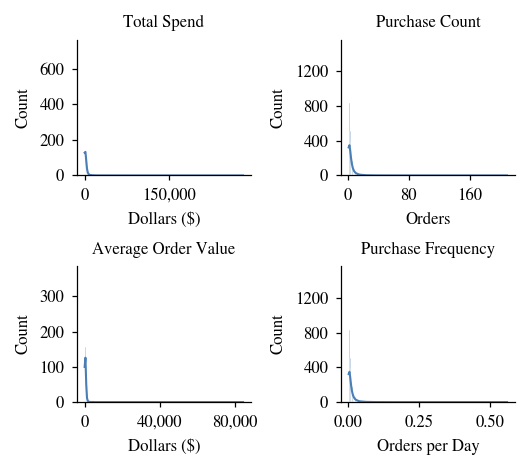

In [35]:
# Fig. 1: raw customer features
fig1(customer_profiles); plt.show()

saved fig2_histograms_log (png + tiff, 300 dpi)


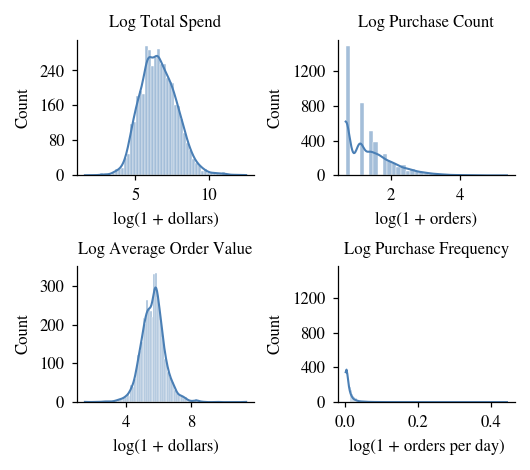

In [36]:
# Fig. 2: log-transformed features
fig2(segmentation_df); plt.show()

saved fig3_elbow_silhouette (png + tiff, 300 dpi)


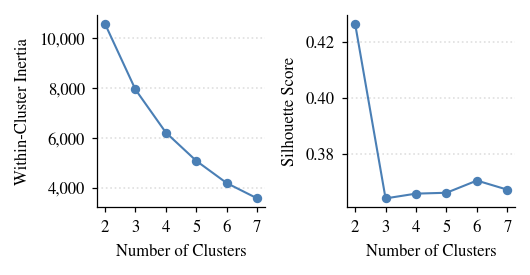

In [37]:
# Fig. 3: elbow + silhouette (uses inertias and sil_scores from the cells above)
fig3(inertias, sil_scores, k_range); plt.show()

saved fig4_noise_results (png + tiff, 300 dpi)


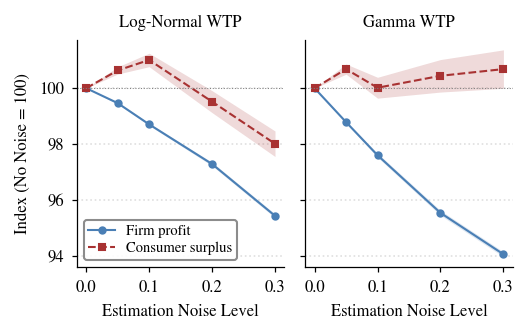

In [38]:
# Fig. 4: Monte Carlo results
fig4(mc_lognormal, sd_lognormal, mc_gamma, sd_gamma); plt.show()

In [39]:
# Download files
!zip -r figures.zip figures
files.download("figures.zip")

  adding: figures/ (stored 0%)
  adding: figures/tiff/ (stored 0%)
  adding: figures/tiff/fig1_histograms_raw.tiff (deflated 12%)
  adding: figures/tiff/fig2_histograms_log.tiff (deflated 7%)
  adding: figures/tiff/fig3_elbow_silhouette.tiff (deflated 5%)
  adding: figures/tiff/fig4_noise_results.tiff (deflated 4%)
  adding: figures/png/ (stored 0%)
  adding: figures/png/fig3_elbow_silhouette.png (deflated 8%)
  adding: figures/png/fig2_histograms_log.png (deflated 9%)
  adding: figures/png/fig4_noise_results.png (deflated 6%)
  adding: figures/png/fig1_histograms_raw.png (deflated 14%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>